# Setup

## Imports

In [1]:
!pip install memory-profiler
!pip install psutil

import geopandas as gpd
from shapely.geometry import Point
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from statistics import mean, stdev
from tqdm import tqdm
from google.colab import drive
import os
import time as t
import heapq
import json
import sys
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import ast
import requests
from geopy.distance import geodesic
import pickle
from shapely.geometry import shape
from memory_profiler import memory_usage
import psutil

## Drive setup

In [2]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [3]:
state_name = "Ohio"
city_name = "Columbus"

if state_name == "District of Columbia":
  city_name = "District of Columbia"

In [4]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
mini = True
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"

In [5]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Files in directory :  ['avg_hotspot_data.json', 'mygraph.json', 'mygraph.graphml', 'ExecutionTime_7_31.txt', 'Temp', 'Processed Location Data', 'Hotspot Data', 'Q Tables', 'Images', 'Original Location Data', 'gh_cache', 'Census Data', 'UMST Graph']


In [6]:
hotspot_dir = os.path.join(data_dir, "Hotspot Data")

# Graph folder
graph_dir = os.path.join(data_dir, "UMST Graph")

# Hotspot + adjacency matrices
hotspot_geojson = os.path.join(hotspot_dir, "hotspot_data.geojson")
dist_mat_path   = os.path.join(hotspot_dir, "estimate_distance_adjacency_matrix.npy")
time_mat_path   = os.path.join(hotspot_dir, "estimate_time_adjacency_matrix.npy")

# UMST & MST Graphs
umst_graphml_path = os.path.join(graph_dir, "umst_graph_msts.graphml.xml")
mst_graphml_path  = os.path.join(graph_dir, "mst_graph.graphml")

# Simulation

**Parameters:**

In [7]:
# =============================================================================
# SECTION 1: CONFIGURATION
# =============================================================================
# --- Simulation Parameters ---
NUM_DELIVERIES = 1000  # Number of random deliveries to simulate
RANDOM_SEED = 42       # Ensures the same "random" deliveries are generated every time

In [8]:
temp_dir = os.path.join(data_dir, "Temp")
graph_dir = os.path.join(data_dir, "UMST Graph")
hotspot_dir = os.path.join(data_dir, "Hotspot Data")

# Path to the complete graph with GraphHopper weights (our source of truth)
FULL_GRAPH_PATH = os.path.join(temp_dir, "gh_hotspot_graph.pkl")

# Path to the UMST graph structure file
# NOTE: You might need to adjust this filename if it's different.
UMST_STRUCTURE_PATH = os.path.join(graph_dir, "umst_graph_msts.graphml.xml")

# Path to the GeoJSON for creating GEOID mappings
HOTSPOT_GEOJSON_PATH = os.path.join(hotspot_dir, "hotspot_data.geojson")

## Helper Functions


In [9]:
def load_full_graph(path):
    """Loads the complete, pickled GraphHopper graph."""
    print(f"Loading full GraphHopper graph from: {path}")
    if not os.path.exists(path):
        print(f"--- ❌ ERROR: Full graph file not found! ---")
        print("Please ensure the generator script has run and created this file.")
        return None
    try:
        with open(path, 'rb') as f:
            graph = pickle.load(f)

        # --- NORMALIZE NODE TYPES ---
        # Check if node types need to be converted from string to integer for consistency.
        sample_node = next(iter(graph.nodes()))
        if isinstance(sample_node, str):
            print("Detected string node IDs in the full graph. Converting to integers...")
            mapping = {node: int(node) for node in graph.nodes() if node.isdigit()}
            if len(mapping) == graph.number_of_nodes():
                graph = nx.relabel_nodes(graph, mapping)
                print("✅ Node IDs successfully converted to integers.")
            else:
                print("--- ⚠️ WARNING: Could not convert all node IDs to integers. Mismatch may still occur. ---")

        # Ensure edge weights are floats, not strings
        for u, v, data in graph.edges(data=True):
            data['distance'] = float(data.get('distance', 0))
            data['time'] = float(data.get('time', 0))
        print(f"✅ Full graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges.")
        return graph
    except Exception as e:
        print(f"--- ❌ ERROR loading pickle file: {e} ---")
        return None


def load_umst_structure(path):
    """Loads the UMST graph structure from a GraphML file."""
    print(f"Loading UMST structure from: {path}")
    if not os.path.exists(path):
        print(f"--- ❌ ERROR: UMST structure file not found! ---")
        return None
    try:
        graph = nx.read_graphml(path)
        # GraphML nodes are strings by default; convert them to integers to match the main graph.
        mapping = {node: int(node) for node in graph.nodes() if node.isdigit()}
        if mapping:
             graph = nx.relabel_nodes(graph, mapping)
        print(f"✅ UMST structure loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges.")
        return graph
    except Exception as e:
        print(f"--- ❌ ERROR loading GraphML file: {e} ---")
        return None


def create_fair_umst(umst_structure, full_graph):
    """
    Creates a "fair" UMST by copying correct GraphHopper weights from the
    full graph onto the UMST's edge structure.
    """
    print("Updating UMST with correct GraphHopper weights for a fair comparison...")
    fair_umst = umst_structure.copy()
    edges_updated = 0
    for u, v in fair_umst.edges():
        if full_graph.has_edge(u, v):
            # Copy all attributes (distance, time, etc.) from the full graph
            fair_umst[u][v].update(full_graph[u][v])
            edges_updated += 1
        else:
            # This case should ideally not happen if the UMST is a subgraph
            print(f"Warning: Edge ({u}, {v}) from UMST not found in the full graph.")
    print(f"✅ Fair UMST created. Updated {edges_updated} edge weights.")
    return fair_umst


def get_path_cost(graph, path):
    """Calculates the total distance and time for a given path in a graph."""
    total_distance = 0.0
    total_time = 0.0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_data = graph.get_edge_data(u, v)
        if edge_data:
            total_distance += edge_data.get('distance', 0.0)
            total_time += edge_data.get('time', 0.0)
    return total_distance, total_time


Loading full GraphHopper graph from: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Temp/gh_hotspot_graph.pkl
Detected string node IDs in the full graph. Converting to integers...
✅ Node IDs successfully converted to integers.
✅ Full graph loaded: 26 nodes, 325 edges.
Loading UMST structure from: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/umst_graph_msts.graphml.xml
✅ UMST structure loaded: 26 nodes, 37 edges.
Updating UMST with correct GraphHopper weights for a fair comparison...
✅ Fair UMST created. Updated 37 edge weights.
Building MST baseline from the full GraphHopper graph...
✅ MST baseline created.

Generated 1000 unique random delivery pairs for simulation.
Running simulation...


Simulating Deliveries: 100%|██████████| 1000/1000 [00:00<00:00, 10257.71it/s]

✅ Simulation complete.

Analyzing results...
Filtered out 0 disconnected routes. Analyzing 1000 valid routes.

PERFORMANCE COMPARISON: MST vs UMST
(Based on 1000 simulated deliveries)

--- Average Performance ---
Avg. MST Distance:   7.77 km
Avg. UMST Distance:  6.20 km

Avg. MST Time:       17.36 min
Avg. UMST Time:      14.77 min

--- Summary of Differences ---
UMST is, on average, 0.90x the distance of MST.
UMST is, on average, 0.95x the travel time of MST.

Total Distance Saved by UMST (vs MST): 1573.25 km
Total Time Saved by UMST (vs MST):   2585.97 min


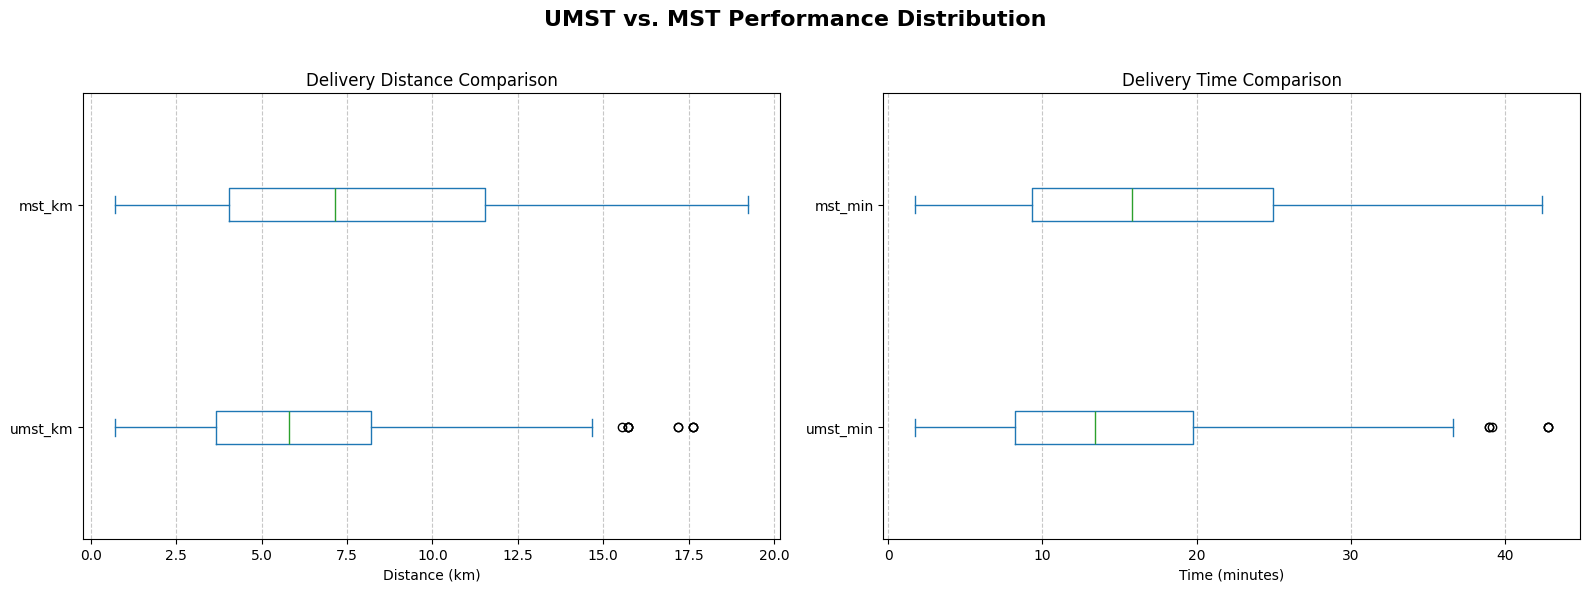

In [10]:
# --- Seed for reproducibility ---
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Step 1: Load the Graphs ---
full_gh_graph = load_full_graph(FULL_GRAPH_PATH)
umst_structure = load_umst_structure(UMST_STRUCTURE_PATH)

# Proceed only if both graphs were loaded successfully
if full_gh_graph and umst_structure:

    # --- Step 2: Create the Fair Comparison Graphs ---
    umst_graph = create_fair_umst(umst_structure, full_gh_graph)

    print("Building MST baseline from the full GraphHopper graph...")
    mst_graph = nx.minimum_spanning_tree(full_gh_graph, weight='distance')
    print("✅ MST baseline created.")


    # --- Step 3: Prepare for Simulation ---
    all_nodes = list(full_gh_graph.nodes())
    delivery_pairs = []
    while len(delivery_pairs) < NUM_DELIVERIES:
        source = random.choice(all_nodes)
        target = random.choice(all_nodes)
        if source != target:
            delivery_pairs.append((source, target))

    print(f"\nGenerated {len(delivery_pairs)} unique random delivery pairs for simulation.")


    # --- Step 4: Run the Simulation ---
    results = []
    print("Running simulation...")
    for src, dst in tqdm(delivery_pairs, desc="Simulating Deliveries"):
        record = {'source': src, 'target': dst}

        # Simulate on MST
        try:
            mst_path = nx.shortest_path(mst_graph, source=src, target=dst, weight='distance')
            mst_dist, mst_time = get_path_cost(mst_graph, mst_path)
            record.update({'mst_distance': mst_dist, 'mst_time': mst_time})
        except nx.NetworkXNoPath:
            record.update({'mst_distance': np.inf, 'mst_time': np.inf})

        # Simulate on UMST
        try:
            umst_path = nx.shortest_path(umst_graph, source=src, target=dst, weight='distance')
            umst_dist, umst_time = get_path_cost(umst_graph, umst_path)
            record.update({'umst_distance': umst_dist, 'umst_time': umst_time})
        except nx.NetworkXNoPath:
            # This can happen if the UMST is disconnected
            record.update({'umst_distance': np.inf, 'umst_time': np.inf})

        results.append(record)

    print("✅ Simulation complete.")


    # =============================================================================
    # SECTION 4: ANALYSIS AND VISUALIZATION
    # =============================================================================

    print("\nAnalyzing results...")
    # --- Step 5: Process Results ---
    df = pd.DataFrame(results)

    # --- FIX: REMOVED INCORRECT UNIT CONVERSION ---
    # The inspection revealed the graph data is already in KM and Minutes.
    # We simply rename the columns for clarity without dividing.
    df['mst_km'] = df['mst_distance']
    df['umst_km'] = df['umst_distance']
    df['mst_min'] = df['mst_time']
    df['umst_min'] = df['umst_time']

    # Filter out any deliveries that were not possible on either graph
    original_count = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    valid_count = len(df)
    print(f"Filtered out {original_count - valid_count} disconnected routes. Analyzing {valid_count} valid routes.")

    # Calculate ratios and differences
    # Avoid division by zero if any mst values are 0
    df['dist_ratio'] = df.apply(lambda row: row['umst_km'] / row['mst_km'] if row['mst_km'] > 0 else 1, axis=1)
    df['time_ratio'] = df.apply(lambda row: row['umst_min'] / row['mst_min'] if row['mst_min'] > 0 else 1, axis=1)
    df['dist_savings_km'] = df['mst_km'] - df['umst_km']
    df['time_savings_min'] = df['mst_min'] - df['umst_min']


    # --- Step 6: Display Summary Statistics ---
    print("\n" + "="*50)
    print("PERFORMANCE COMPARISON: MST vs UMST")
    print(f"(Based on {valid_count} simulated deliveries)")
    print("="*50)

    # Average Performance
    avg_mst_dist = df['mst_km'].mean()
    avg_umst_dist = df['umst_km'].mean()
    avg_mst_time = df['mst_min'].mean()
    avg_umst_time = df['umst_min'].mean()

    print("\n--- Average Performance ---")
    print(f"Avg. MST Distance:   {avg_mst_dist:.2f} km")
    print(f"Avg. UMST Distance:  {avg_umst_dist:.2f} km")
    print(f"\nAvg. MST Time:       {avg_mst_time:.2f} min")
    print(f"Avg. UMST Time:      {avg_umst_time:.2f} min")

    # Overall Savings & Ratios
    total_dist_savings = df['dist_savings_km'].sum()
    total_time_savings = df['time_savings_min'].sum()
    avg_dist_ratio = df['dist_ratio'].mean()
    avg_time_ratio = df['time_ratio'].mean()

    print("\n--- Summary of Differences ---")
    print(f"UMST is, on average, {avg_dist_ratio:.2f}x the distance of MST.")
    print(f"UMST is, on average, {avg_time_ratio:.2f}x the travel time of MST.")
    print(f"\nTotal Distance Saved by UMST (vs MST): {total_dist_savings:.2f} km")
    print(f"Total Time Saved by UMST (vs MST):   {total_time_savings:.2f} min")
    print("="*50)


    # --- Step 7: Visualize the Results ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('UMST vs. MST Performance Distribution', fontsize=16, fontweight='bold')

    # Distance Comparison Plot
    df[['umst_km', 'mst_km']].plot(kind='box', ax=axes[0], vert=False)
    axes[0].set_title('Delivery Distance Comparison', fontsize=12)
    axes[0].set_xlabel('Distance (km)')
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)

    # Time Comparison Plot
    df[['umst_min', 'mst_min']].plot(kind='box', ax=axes[1], vert=False)
    axes[1].set_title('Delivery Time Comparison', fontsize=12)
    axes[1].set_xlabel('Time (minutes)')
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

else:
    print("\n--- ❗ Halting execution due to file loading errors. Please check paths and file availability. ---")

Running Extended Analysis: Comparing against the Fully Connected Graph...
Simulating deliveries on the full graph (theoretical best path)...


Simulating on Full Graph: 100%|██████████| 1000/1000 [00:00<00:00, 2076.50it/s]


✅ Full graph simulation complete.
✅ Merged all simulation results into a final DataFrame.

FINAL PERFORMANCE COMPARISON: MST vs UMST vs Full Graph
(Based on 2586 simulated deliveries)

--- Average Delivery Distance ---
Full Graph: 4.41 km (Theoretical Best)
MST:        7.85 km
UMST:       6.24 km

--- Average Delivery Time ---
Full Graph: 8.94 min (Theoretical Best)
MST:        17.55 min
UMST:       14.94 min

--- Path Overhead (How much longer are the paths?) ---
MST paths are, on average, 1.76x longer than the optimal path.
UMST paths are, on average, 1.41x longer than the optimal path.


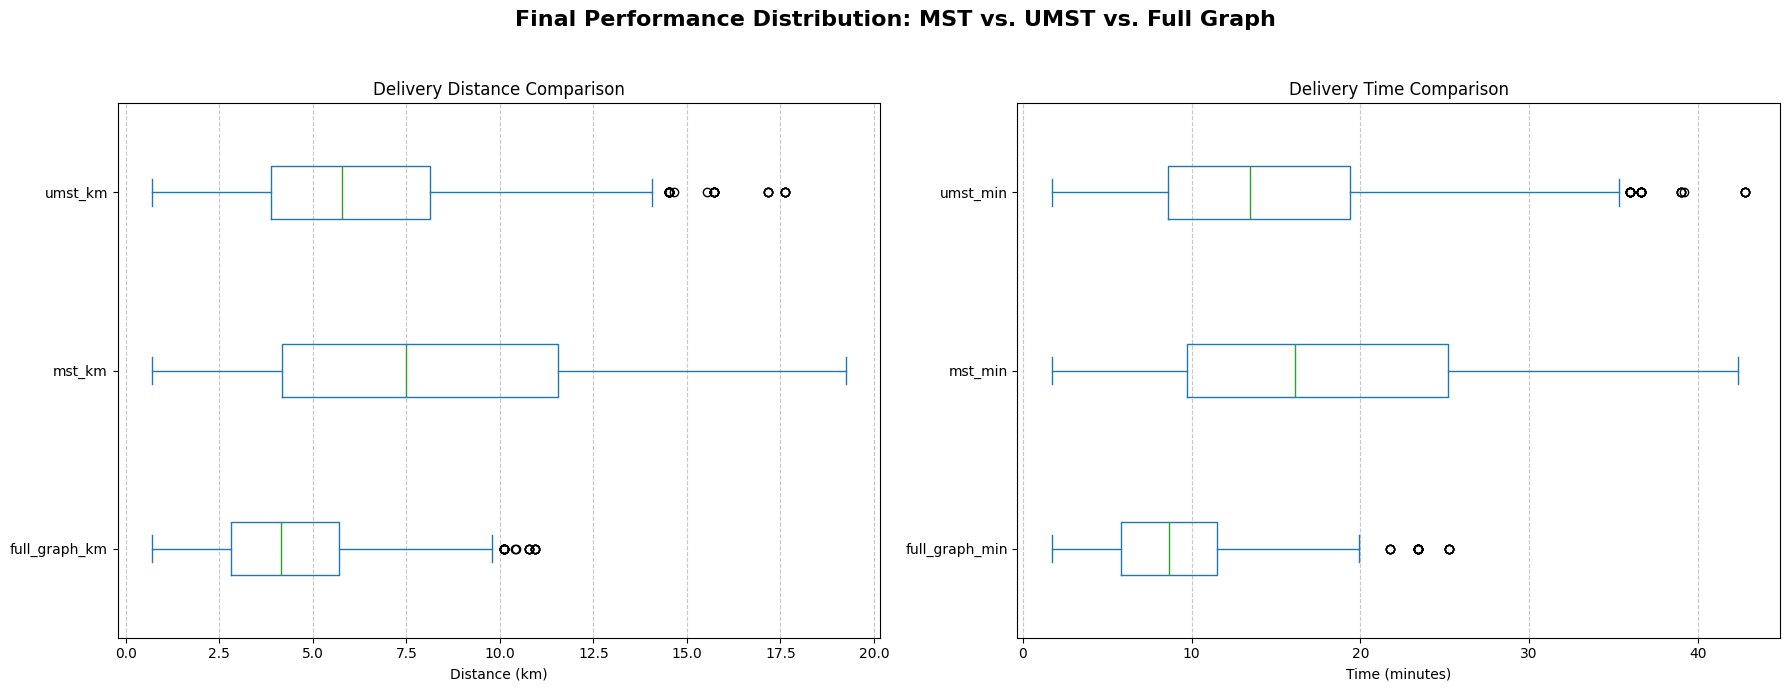

In [11]:
# =============================================================================
# SECTION 5: EXTENDED ANALYSIS vs. FULLY CONNECTED GRAPH
# =============================================================================
# This script assumes the previous cell has been run and the following
# variables are in memory:
#   - full_gh_graph: The complete GraphHopper graph.
#   - delivery_pairs: The list of 1000 (source, target) tuples.
#   - df: The pandas DataFrame containing the MST and UMST simulation results.
#   - get_path_cost: The helper function.

print("="*60)
print("Running Extended Analysis: Comparing against the Fully Connected Graph...")
print("="*60)

# --- Step 5a: Simulate Deliveries on the Full Graph ---
# We use the *same* delivery_pairs list for a fair comparison.
full_graph_results = []
print("Simulating deliveries on the full graph (theoretical best path)...")
for src, dst in tqdm(delivery_pairs, desc="Simulating on Full Graph"):
    record = {'source': src, 'target': dst}
    try:
        # Find the shortest path in the complete road network graph
        path = nx.shortest_path(full_gh_graph, source=src, target=dst, weight='distance')
        dist, time = get_path_cost(full_gh_graph, path)
        record.update({'full_graph_km': dist, 'full_graph_min': time})
    except nx.NetworkXNoPath:
        # This is highly unlikely in a fully connected graph but good practice
        record.update({'full_graph_km': np.inf, 'full_graph_min': np.inf})
    full_graph_results.append(record)

print("✅ Full graph simulation complete.")

# --- Step 5b: Merge Results into a Single DataFrame ---
# Create a new DataFrame for the full graph results
df_full = pd.DataFrame(full_graph_results)

# Merge with the existing DataFrame from the previous cell
# This aligns the results for each specific delivery
df_final = pd.merge(df, df_full, on=['source', 'target'])
print("✅ Merged all simulation results into a final DataFrame.")

# --- Step 5c: Display the Final 3-Way Comparison Summary ---
print("\n" + "="*50)
print("FINAL PERFORMANCE COMPARISON: MST vs UMST vs Full Graph")
print(f"(Based on {len(df_final)} simulated deliveries)")
print("="*50)

# Calculate averages for all three graphs
avg_mst_dist = df_final['mst_km'].mean()
avg_umst_dist = df_final['umst_km'].mean()
avg_full_dist = df_final['full_graph_km'].mean()

avg_mst_time = df_final['mst_min'].mean()
avg_umst_time = df_final['umst_min'].mean()
avg_full_time = df_final['full_graph_min'].mean()

print("\n--- Average Delivery Distance ---")
print(f"Full Graph: {avg_full_dist:.2f} km (Theoretical Best)")
print(f"MST:        {avg_mst_dist:.2f} km")
print(f"UMST:       {avg_umst_dist:.2f} km")

print("\n--- Average Delivery Time ---")
print(f"Full Graph: {avg_full_time:.2f} min (Theoretical Best)")
print(f"MST:        {avg_mst_time:.2f} min")
print(f"UMST:       {avg_umst_time:.2f} min")

# Calculate ratios relative to the optimal (full graph) path
df_final['mst_dist_overhead'] = df_final['mst_km'] / df_final['full_graph_km']
df_final['umst_dist_overhead'] = df_final['umst_km'] / df_final['full_graph_km']

print("\n--- Path Overhead (How much longer are the paths?) ---")
print(f"MST paths are, on average, {df_final['mst_dist_overhead'].mean():.2f}x longer than the optimal path.")
print(f"UMST paths are, on average, {df_final['umst_dist_overhead'].mean():.2f}x longer than the optimal path.")
print("="*50)

# --- Step 5d: Visualize the 3-Way Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Final Performance Distribution: MST vs. UMST vs. Full Graph', fontsize=16, fontweight='bold')

# Columns to plot
dist_cols = ['full_graph_km', 'mst_km', 'umst_km']
time_cols = ['full_graph_min', 'mst_min', 'umst_min']

# Distance Comparison Plot
df_final[dist_cols].plot(kind='box', ax=axes[0], vert=False)
axes[0].set_title('Delivery Distance Comparison', fontsize=12)
axes[0].set_xlabel('Distance (km)')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Time Comparison Plot
df_final[time_cols].plot(kind='box', ax=axes[1], vert=False)
axes[1].set_title('Delivery Time Comparison', fontsize=12)
axes[1].set_xlabel('Time (minutes)')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
